In [1]:
!pip install cirq qiskit==1.4.2 qiskit-aer==0.16.1 amazon-braket-sdk pennylane --quiet
!pip install matplotlib pylatexenc --quiet

In [2]:
import cirq
import matplotlib.pyplot as plt
import numpy as np
import math

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import MCMT
from qiskit.quantum_info import Statevector

from braket.circuits import Circuit
from braket.devices import LocalSimulator

import pennylane as qml

# Algorithme de grover


In [3]:
n = 3
solution = "110101"
max_iter = int(np.floor(math.pi / 4 * math.sqrt(2**n)))
print(f"Nombre itération : {max_iter}")

Nombre itération : 2


In [4]:
def plot_probs(probs, step):
  etiquettes = [format(i, f'0{n}b') for i in range(len(probs))]
  plt.figure(figsize=(9, 3))
  barres = plt.bar(etiquettes, probs, color='#4285F4')
  plt.title(f"Probabilités (Algorithme de Grover, etape={step})")
  plt.xlabel("États Quantiques")
  plt.ylabel("Probabilité")
  plt.ylim(0, 1.1) # Fixe l'axe Y de 0 à 1.1 (pour laisser de la place au texte)
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.show()

### Version Qiskit

/tmp/ipykernel_103997/1121046532.py:1: DeprecationWarning: The class ``qiskit.circuit.library.generalized_gates.mcmt.MCMT`` is deprecated as of qiskit 1.4. It will be removed no earlier than 3 months after the release date. Use MCMTGate instead.
  mcz = MCMT('cz', n-1, 1)


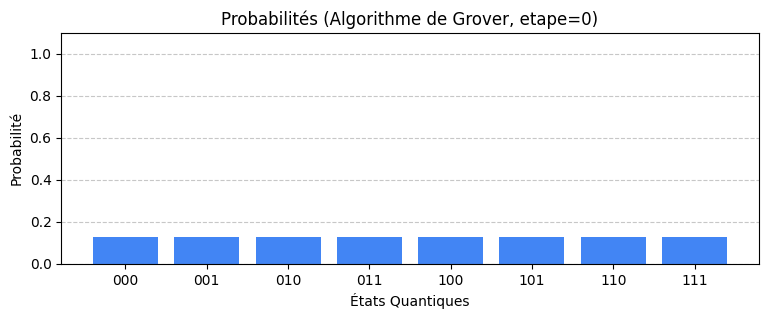

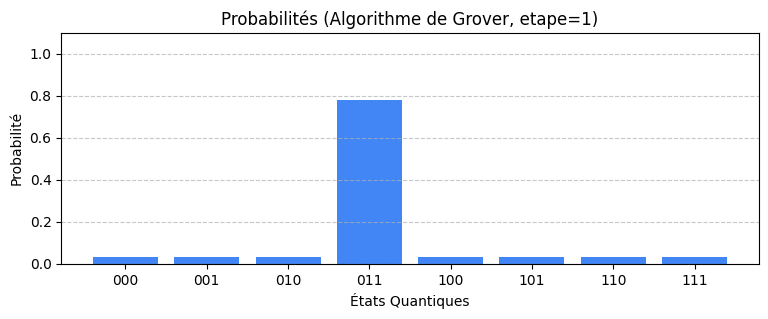

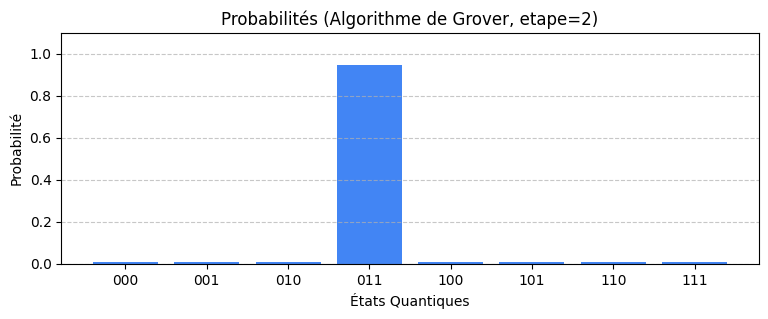

[array([0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125]), array([0.03125, 0.03125, 0.03125, 0.78125, 0.03125, 0.03125, 0.03125,
       0.03125]), array([0.0078125, 0.0078125, 0.0078125, 0.9453125, 0.0078125, 0.0078125,
       0.0078125, 0.0078125])]


In [5]:
mcz = MCMT('cz', n-1, 1)
a = QuantumRegister(n, "a")
res = ClassicalRegister(n, "result")
qc = QuantumCircuit(a, res)
probs = []

qc.barrier()

qc.h(a)

state = Statevector(qc)
prob = state.probabilities()
probs.append(prob)
plot_probs(prob, 0)

for step in range(max_iter):
  qc.barrier(label="Marking phase (oracle)")
  for i in range(n):
    if solution[i] == "0":
      qc.x(a[i])

  qc.compose(mcz, inplace=True)

  for i in range(n):
    if solution[i] == "0":
      qc.x(a[i])

  qc.barrier(label="Diffusion phase")

  qc.h(a)
  qc.x(a)
  qc.compose(mcz, inplace=True)
  qc.x(a)
  qc.h(a)

  state = Statevector(qc)
  prob = state.probabilities()
  probs.append(prob)
  plot_probs(prob, step+1)


qc.barrier(label="End")

qc.measure(a, res[::-1])
qc.draw(output="mpl")
print(probs)

{'100': 1, '110': 39}


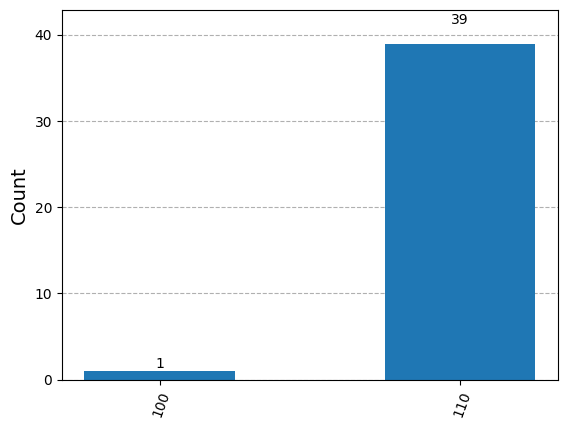

In [6]:
Simulator= AerSimulator()
#Converts your circuit into a form the simulator understands
compile=transpile(qc,Simulator)
#run(...): Executes the circuit
#shots=20: Runs the circuit 20 times
#result(): Gets the execution result
#get_counts(): Returns how many times each result appeared
result= Simulator.run(compile, shots=40).result().get_counts()
print(result)
plot_histogram(result)

### Version Cirq

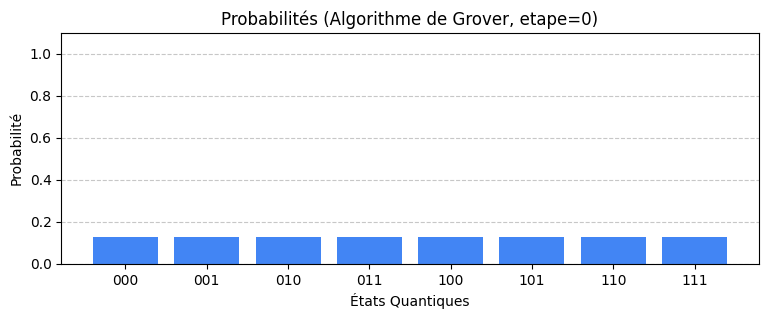

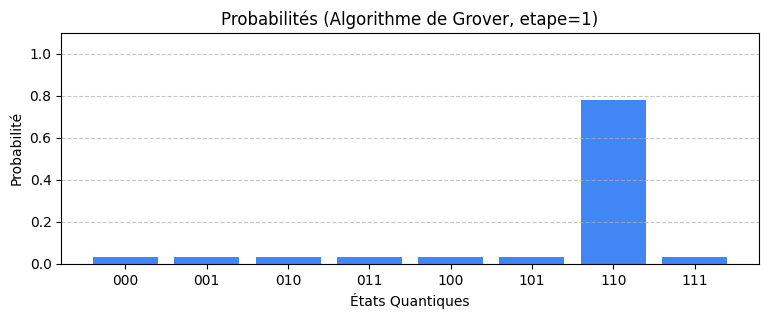

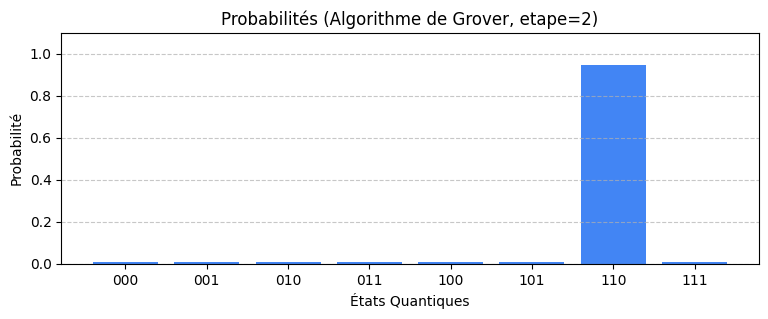

0: ───H───────@───H───X───────@───X───H───────@───H───X───────@───X───H───M('res')───
              │               │               │               │           │
1: ───H───────@───H───X───────@───X───H───────@───H───X───────@───X───H───M──────────
              │               │               │               │           │
2: ───H───X───@───X───H───X───@───X───H───X───@───X───H───X───@───X───H───M──────────
[array([0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125]), array([0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.78125,
       0.03125]), array([0.0078125, 0.0078125, 0.0078125, 0.0078125, 0.0078125, 0.0078125,
       0.9453125, 0.0078125])]


In [7]:
a = cirq.LineQubit.range(n)
mcz = cirq.Z.controlled(n-1)
circuit = cirq.Circuit()
probs = []

circuit.append(cirq.H.on_each(*a))
prob = np.abs(circuit.final_state_vector())**2
plot_probs(prob, 0)
probs.append(prob)


for step in range(max_iter):
  for i in range(n):
    if solution[i] == "0":
      circuit.append(cirq.X(a[i]))
  circuit.append(mcz(*a))
  for i in range(n):
    if solution[i] == "0":
      circuit.append(cirq.X(a[i]))

  circuit.append(cirq.H.on_each(*a))
  circuit.append(cirq.X.on_each(*a))
  circuit.append(mcz(*a))
  circuit.append(cirq.X.on_each(*a))
  circuit.append(cirq.H.on_each(*a))

  prob = np.abs(circuit.final_state_vector())**2
  plot_probs(prob, step+1)
  probs.append(prob)

circuit.append(cirq.measure(*a, key="res"))
print(circuit)
print(probs)

In [8]:
simulator = cirq.Simulator()
result = simulator.run(circuit, repetitions=100)

print(result.histogram(key='res'))

Counter({6: 94, 4: 1, 3: 1, 2: 1, 5: 1, 1: 1, 0: 1})


### Version Pennylane

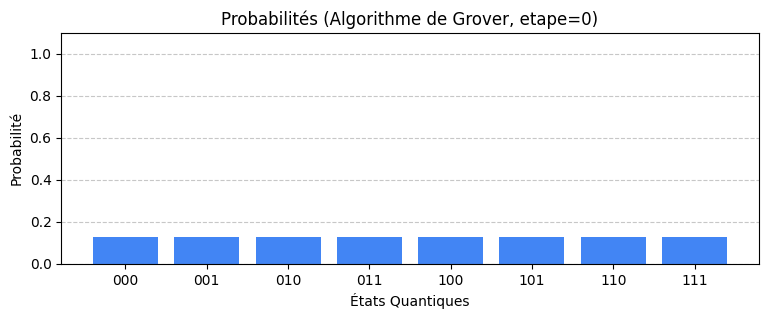

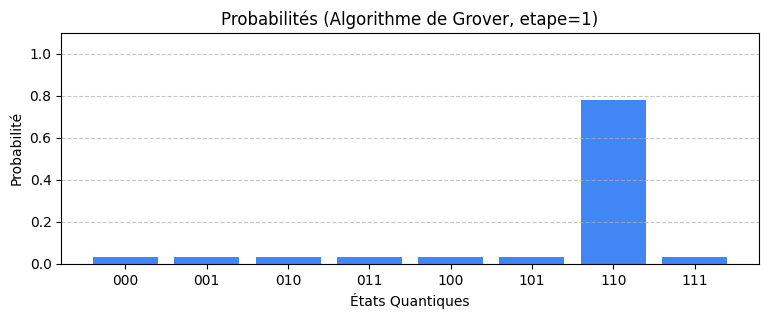

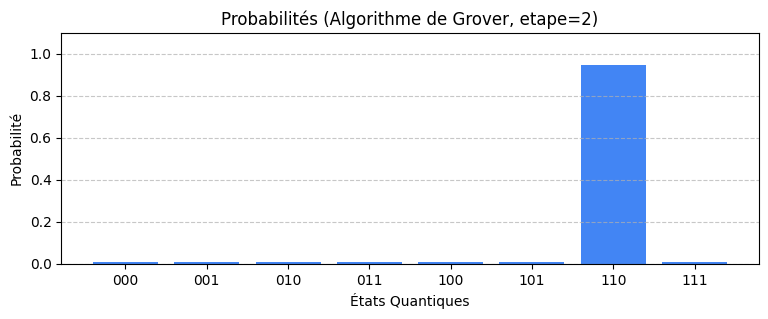

{'000': 7, '001': 7, '010': 7, '011': 7, '100': 7, '101': 7, '110': 945, '111': 7}


In [9]:
wires      = list(range(n))
dev        = qml.device("default.qubit", wires=wires)
probs = []

def oracle():
    for i in range(n):
        if solution[i] == "0": qml.PauliX(wires=i)
    qml.ctrl(qml.PauliZ, control=wires[:-1])(wires=wires[-1])
    for i in range(n):
        if solution[i] == "0": qml.PauliX(wires=i)

def diffusion():
    for i in wires: qml.Hadamard(wires=i)
    for i in wires: qml.PauliX(wires=i)
    qml.ctrl(qml.PauliZ, control=wires[:-1])(wires=wires[-1])
    for i in wires: qml.PauliX(wires=i)
    for i in wires: qml.Hadamard(wires=i)

@qml.qnode(dev)
def grover():
    for i in wires:
        qml.Hadamard(wires=i)
    qml.Snapshot(tag="Init")
    for step in range(max_iter):
        oracle()
        diffusion()
        qml.Snapshot(tag=f"Iteration_{step + 1}")
    return qml.probs(wires=wires)

probs = qml.snapshots(grover)()
for step, (key, value) in enumerate(list(probs.items())[:-1]):
  prob = np.abs(value)**2
  plot_probs(prob, step)
counts = {format(i, f"0{n}b"): int(p * 1000)
          for i, p in enumerate(probs['execution_results'])}
print(counts)

# Rapport

## Questions

### 1. Generation of the uniform superposition state

**Question: "How is the uniform superposition state generated from the initial state ∣ 00 … 0⟩?"**

The initial state is transformed into a uniform superposition state by applying a Hadamar gate to each qubit independently. The gate allow each basic state to receive equal amplitude of 1/√𝑁.

### 2. Implementation of the Oracle

**Question: "How is the oracle implemented to mark the target state ∣ 𝜔⟩?"**

The target state is marked by inverting it's phase and leaving all the others unchanged.
In the implementation, we make it by :
- Iterating through all states, applying an X gate to the state == 0
- Applying an MCZ to all states
- In a second iteration, applying again an X gate to revert the previous X gates

Every librairy have it's own operator for the MCZ and the X gate already implemented.

### 3. Implementation of the diffusion operator

**Question: "How is the diffusion operator 𝐷 implemented in each environment?"**

The diffusion operator reflect all values around their average, and is generally implemented by applying the gates H, X, MCZ, X and H.

In **Quiskit**, the gates H and X are in the librairie and are applied with `qc.h(a)` and `qc.x(a)`. The MCZ is also provided and applied with `qc.compose(mcz, inplace=True)`, where `mcz = MCMT('cz', n-1, 1)`.  

The librairie provide multi-controlled gates which can be parametrized. When we use `MCMT('cz', n-1, 1)`, the librairie will automatically build a multi-controlled gate Z with n-1 bits of control and 1 target bit. It chooses a decomposition and optimize the execution to reduce the code necessary.

**Cirq** is more centered around the gates. When we call `mcz_gate = cirq.Z.controlled(n - 1)`, we ask for a gate Z with n-1 bits of control. Cirq will then create a `ControlGate(Z)` and will either simulate it directly or decompose it later in the compilation. This behaviour allow late optimizations as the decomposition is not made directly.

Finally, **Pennylane** is more centered around parametric circuits and functionnal abstraction. When we do `qml.ctrl(qml.PauliZ, control=wires[:-1])`, it doesn't create a physical gate. It creates a functional transformation, containing an operation and the bit of control. The backend (default.qubit (native), Quiskit, Bracket) will then choose a decomposition to apply.

### 4. Evolution of probability distribution

**Question: "How does the probability distribution evolve after each Grover iteration?"**

After each iteration, the probability amplitude of the correct state is amplified and all the others are reduced. As we can see in the images from the compilation (probability, step 0, 1, 2), each iteration make the gap between the target value and the others even bigger.

### 5. Optimal number of iterations

**Question: "Demonstrate why the optimal number of Grover iterations is approximately : `𝑘 ≈ (𝜋 / 4) * √𝑁` and explain why applying additional iterations can decrease the probability amplitude of the marked state ∣ 𝜔⟩."**

Grover's algorithm can be seen geometrically as a rotation of the quantum state vector toward the marked state.

At each iteration, the vector will be rotated by a small portion from the initial amplitude `1/√𝑁` toward the marked state (represented as the vertical axis), and this portion will decrease over time. The factor `(𝜋 / 4)` represents the total rotation angle required for the probability vector to reach the marked state from the initial state, corresponding to a quarter turn toward the marked state.

The second factor `√𝑁` is directly dependant of the Hadamard gate used to create the initial uniform superposition state. Each basic amplitude have an equal value of `1/√𝑁`, which is smaller with a bigger number of state and will also increase the number of rotations required. For the target value to reach the desired rotation, we have to apply this factor of `√𝑁` to take the number of quibit in account.

Applying additional iterations after the optimal value is reached will decreases the marked state probability because the rotation will continue past the marked state. It will then start to move away from the solution, reducing the probability of the marked state instead of increasing it.

### 6. Differences between environnements

**Question: "What are the main differences between Qiskit and the two selected environments in terms of syntax, abstraction level, usability, and execution workflow?"**

**Qiskit** is relatively high-level and hardware-oriented. Quantum circuits are built by directly applying gates to qubits with instructions such as `qc.h(a)`. It also provides multi-controlled gates and tools to simplify the implementation overall.

**Cirq** is more gate-oriented. Gates are treated like explicit object that can be attached later to circuits. Controlled operations are abstract until the compilation, which allow late optimization depending on the target compiler. It provides more controle over circuit construction and hardware constraints, which is well suited for experimentations.

**PennyLane** is built around parametric circuit and for functionnal abstraction. Instead of the hardware-oriented gates objects of Cirq, we use functional transformation containing the operation the bit of control. It is an abstraction layer capable of using multiple backend such as each of the 3 other librairies.

For the usability, Qiskit is the easiest of the 3 because of all the tools and operations provided. Cirq require a better understanding of the gates but remain quite close to the theoric construction of the circuit. PennyLane is the biggest abstraction and is better suited for the complex quantum circuits.

The execution workflow is also different. Qiskit have a typical workflow following the structure circuit → transpilation → execution. Cirq delays part of the decomposition and optimization until compilation. PennyLane instead defines quantum nodes that are executed through a selected backend, separating the algorithm description from the execution device.